In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.transpiler import Target, CouplingMap
from qiskit.quantum_info import Operator
from qiskit_device_benchmarking.bench_code.mrb import MirrorQA, QuantumAwesomeness
import time
import os, random

# Fix random seed for numpy
SEED = 123 # pick your favorite int
os.environ["PYTHONHASHSEED"] = str(SEED)  # optional, for hash-based determinism
random.seed(SEED)
np.random.seed(SEED)

# Initialize the Aer simulator
#sim = AerSimulator(seed_simulator=SEED)

# Define parameters for the simulated backend
num_qubits = 28
basis_gates = ["id", "h", "x", "y", "z", "rz", "cx"]
p2 = 1e-3 # 2-qubit gate error probability
p1 = p2/10  # 1-qubit gate error probability
rz_angle = np.pi / 2  # Match initial_entangling_angle
shots = 10000
lengths = [2]+[4,10,20,50]
num_samples = 20
 
# Create a coupling map as a list of tuples
# Define the connections (edges) between qubits
# Loop 3-4-5-6-7-17-27-26-25-24-23-16-3
fez_loop = [3,4,5,6,7,16,17,23,24,25,26,27]
fez_edges = [(3,4), (4,5), (5,6), (6,7), (7,17), (17,27), (27,26), (26,25), (25,24), (24,23), (23,16), (16,3)]

# Make bidirectional edges
fez_edges += [(b, a) for (a, b) in fez_edges]
# Create the coupling map
coupling_map = CouplingMap(couplinglist=fez_edges)

# Create a Target object to define the gates, including rz explicitly
target = Target.from_configuration(
    num_qubits=num_qubits,
    basis_gates=basis_gates,
    coupling_map=coupling_map,
    custom_name_mapping={
        "id": Operator(np.array([[1, 0], [0, 1]])),  # Identity gate
        "h": Operator(np.array([[1, 1], [1, -1]]) / np.sqrt(2)),  # Hadamard gate
        "x": Operator(np.array([[0, 1], [1, 0]])),  # Pauli X gate
        "y": Operator(np.array([[0, -1j], [1j, 0]])),  # Pauli Y gate
        "z": Operator(np.array([[1, 0], [0, -1]])),  # Pauli Z gate
        "rz": Operator([[np.cos(rz_angle / 2), -1j*np.sin(rz_angle / 2)],
                        [-1j*np.sin(rz_angle / 2), np.cos(rz_angle / 2)]]),  # RZ(π/2)
        "cx": Operator(np.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]]))  # CNOT gate
    }
)

# Create a noise model to emulate the NoisyBackend
noise_model = NoiseModel()

# Add depolarizing errors for 1-qubit and 2-qubit gates
error_1q = depolarizing_error(p1, 1)
error_2q = depolarizing_error(p2, 2)

# Apply errors to all basis gates except 'delay' and 'reset'
for gate in basis_gates:
    if gate in ["id", "h", "x", "y", "z", "rz"]:
        noise_model.add_all_qubit_quantum_error(error_1q, gate)
    elif gate == "cx":
        noise_model.add_all_qubit_quantum_error(error_2q, gate)

# Set up the AerSimulator with stabilizer method, target, and noise model
backend = AerSimulator(
    method="stabilizer",
    noise_model=noise_model if (p1 > 0 or p2 > 0) else None,
    target=target,
    max_parallel_threads=0,
    max_parallel_experiments=0,
    seed_simulator=SEED
)

# Set up the experiment object
exp = MirrorQA(
    fez_loop,
    lengths=lengths,
    backend=backend,
    two_qubit_gate_density=0.25,
    num_samples=num_samples,
    initial_entangling_angle=np.pi/2, seed=SEED,
    #sampling_algorithm='matching'
)

# Set run options
exp.set_run_options(shots=shots)

# Run the experiment
rb_data = exp.run()
print("Job IDs:", rb_data.job_ids)


Job IDs: ['13666dce-8f77-44b3-b33f-a53d7b4079da']


In [2]:
exp.analysis.set_options(analyzed_quantity='Effective Polarization')
analysis = exp.analysis.run(rb_data)

In [3]:
metadata = rb_data.metadata
physical_qubits = metadata.get('physical_qubits', 'Not found')
print(f"Physical qubits used: {physical_qubits}")
print(f"Number of physical qubits: {len(physical_qubits) if isinstance(physical_qubits, list) else 'N/A'}")

Physical qubits used: [3, 4, 5, 6, 7, 16, 17, 23, 24, 25, 26, 27]
Number of physical qubits: 12


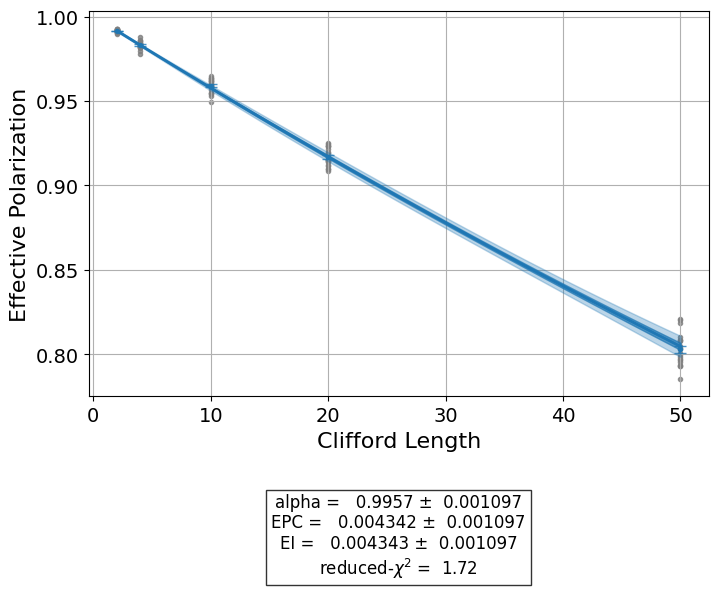

In [5]:
analysis.figure(0)

In [17]:
mmi = qa.mean_mutual_info(rb_data.data(), exp._pairs)

ys = [[[] for _ in range(5)] for _ in range(3)]
yerrs = [[],[],[]]

for p, pairtype in enumerate(['paired', 'unpaired', 'singles']):
    for j,m in enumerate(mmi[pairtype]):
        if m is not np.nan:
            ys[p][j%5].append(m)
    for j in range(5):
        yerrs[p].append(np.std(ys[p][j]))
        ys[p][j] = np.mean(ys[p][j])

plt.errorbar(lengths,ys[0],yerr=yerrs[0],label='paired')
plt.errorbar(lengths,ys[1],yerr=yerrs[1],label='unpaired')
plt.errorbar(lengths,ys[2],yerr=yerrs[2],label='singles')
plt.yscale('log')
plt.legend()

IndexError: string index out of range

In [8]:
qa = QuantumAwesomeness(exp.backend.coupling_map)
mi = qa.mutual_info(rb_data.data())
mmi = qa.mean_mutual_info(rb_data.data(), exp._pairs)

ys = [[[] for _ in range(5)] for _ in range(3)]
yerrs = [[],[],[]]

for p, pairtype in enumerate(['paired', 'unpaired', 'singles']):
    for j,m in enumerate(mmi[pairtype]):
        if not np.isnan(m):
            ys[p][j%5].append(m)
    for j in range(5):
        yerrs[p].append(np.std(ys[p][j]))
        ys[p][j] = np.mean(ys[p][j])

plt.errorbar(lengths,ys[0],yerr=yerrs[0],label='paired')
plt.errorbar(lengths,ys[1],yerr=yerrs[1],label='unpaired')
plt.errorbar(lengths,ys[2],yerr=yerrs[2],label='singles')
plt.yscale('log')
plt.legend()

IndexError: string index out of range